# Uplift Modelling with Meta-Learners
### Causal Data Science Project

This notebook walks through the full pipeline interactively.
All heavy lifting is in `src/` — this notebook is for exploration and presentation.

**Contents**
1. Data loading & EDA
2. Causal framework recap
3. Fit S / T / X-Learners
4. Evaluate with Qini curves
5. Targeting policy & budget optimisation
6. CATE deep-dive by segment

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from data_loader      import load_processed, get_feature_cols
from uplift_models    import get_all_variants
from evaluation       import auqc, qini_curve, random_baseline_qini
from targeting_policy import policy_summary, budget_sweep
from visualizations   import (
    plot_eda_overview, plot_uplift_distribution, plot_qini_curves,
    plot_cumulative_gain, plot_feature_importance, plot_budget_curve,
    plot_cate_heatmap, plot_model_comparison
)

## 1. Data Loading & EDA

In [2]:
df = load_processed()
df[['segment','visit','conversion','spend']].groupby('segment').agg(
    n=('visit','count'),
    visit_rate=('visit','mean'),
    conv_rate=('conversion','mean'),
    avg_spend=('spend','mean')
).round(4)

[data_loader] Loading cached dataset from data/
[data_loader] Processed dataset saved to data/


,n,visit_rate,conv_rate,avg_spend
segment,,,,
Mens E-Mail,21291,0.1513,0.0666,9.1601
No E-Mail,21438,0.1084,0.0463,6.2644
Womens E-Mail,21271,0.1502,0.0634,8.5072


[viz] Saved → outputs/figures/01_eda_overview.png


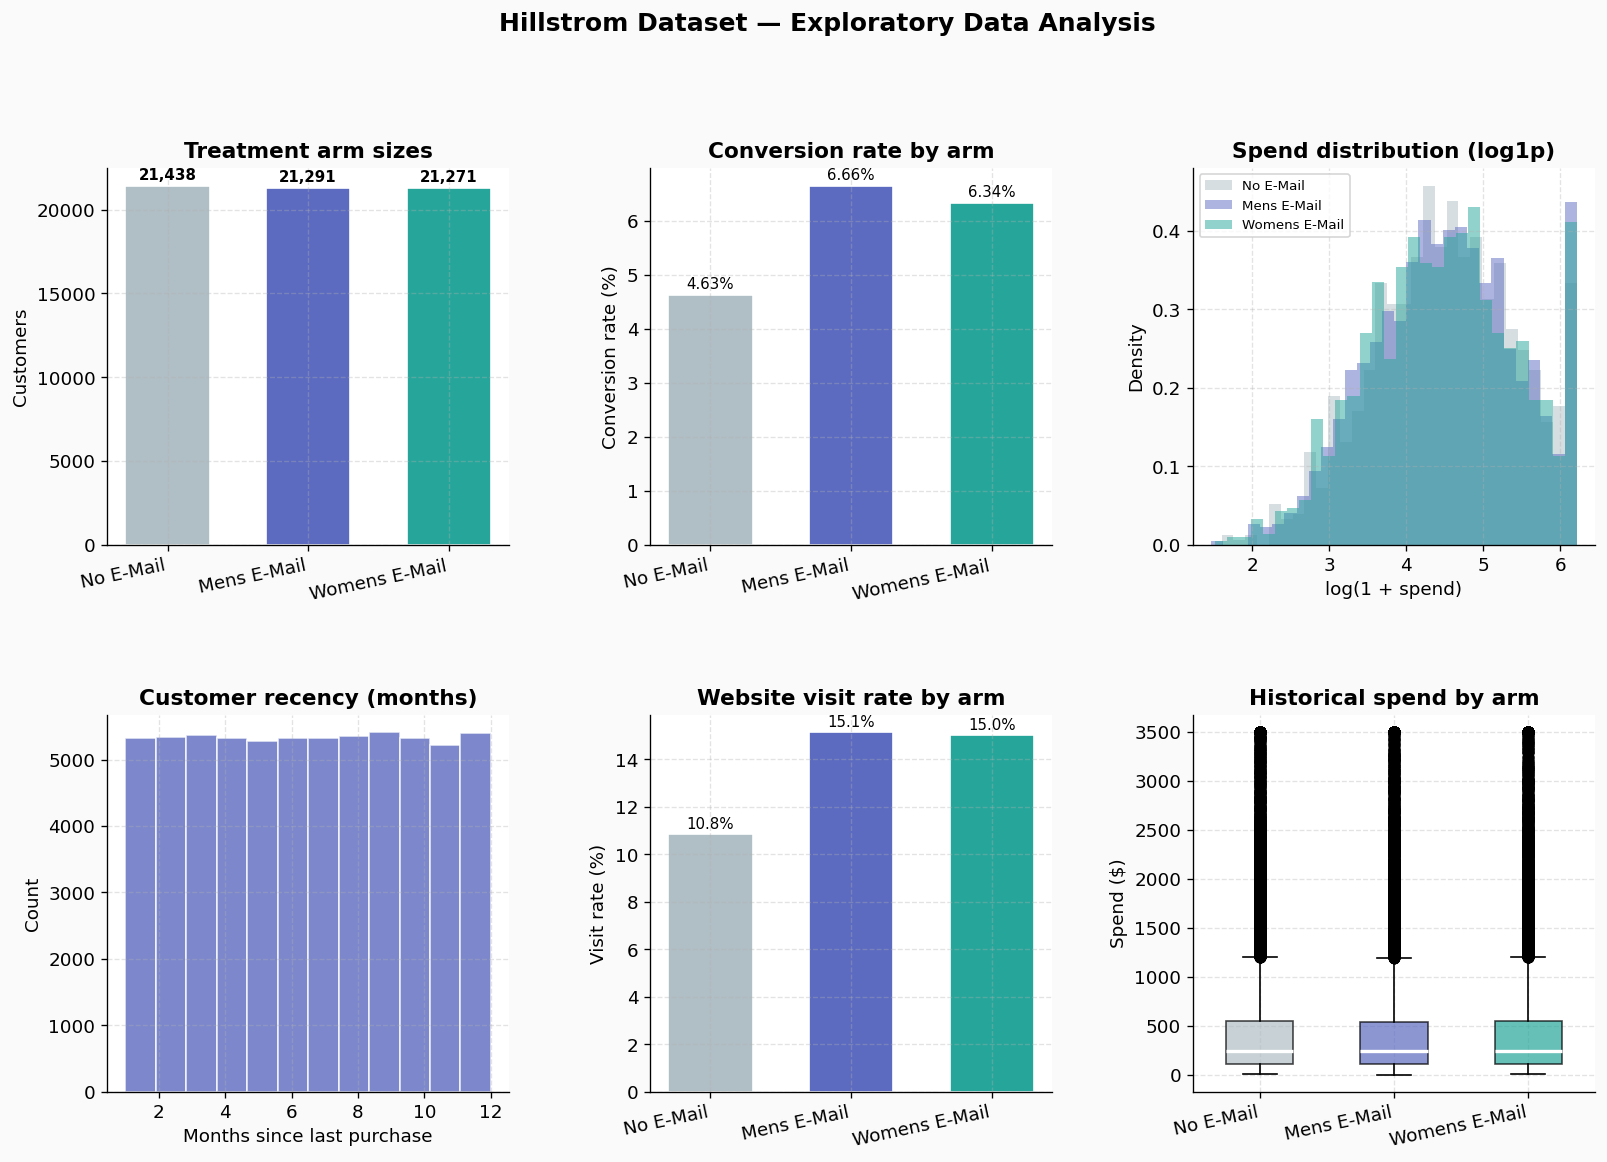

In [3]:
plot_eda_overview(df)
plt.show()

## 2. Train / Test Split

In [4]:
from sklearn.model_selection import train_test_split

feature_cols = get_feature_cols()
X         = df[feature_cols]
treatment = df['treatment_binary'].values
y         = df['conversion'].values

X_tr, X_te, t_tr, t_te, y_tr, y_te = train_test_split(
    X, treatment, y, test_size=0.30, random_state=42, stratify=treatment
)

# Class imbalance diagnostics
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
spw   = n_neg / n_pos

pd.DataFrame({
    'Split':            ['Train', 'Test'],
    'N':                [len(X_tr), len(X_te)],
    'Treatment rate':   [f'{t_tr.mean():.3f}', f'{t_te.mean():.3f}'],
    'Conversion rate':  [f'{y_tr.mean():.3f}', f'{y_te.mean():.3f}'],
    'scale_pos_weight': [f'{spw:.1f}', '—'],
}).set_index('Split')

,N,Treatment rate,Conversion rate,scale_pos_weight
Split,,,,
Train,44800,0.665,0.058,16.1
Test,19200,0.665,0.059,—


## 3. Fit All Models (S / T / X-Learner × Calibration)

In [5]:
models    = get_all_variants(outcome='binary')
cate_dict = {}

for model in models:
    model.fit(X_tr, t_tr, y_tr)
    cate = model.predict(X_te)
    cate_dict[model.name] = cate

## 4. CATE Distributions

[viz] Saved → outputs/figures/02_cate_distributions.png


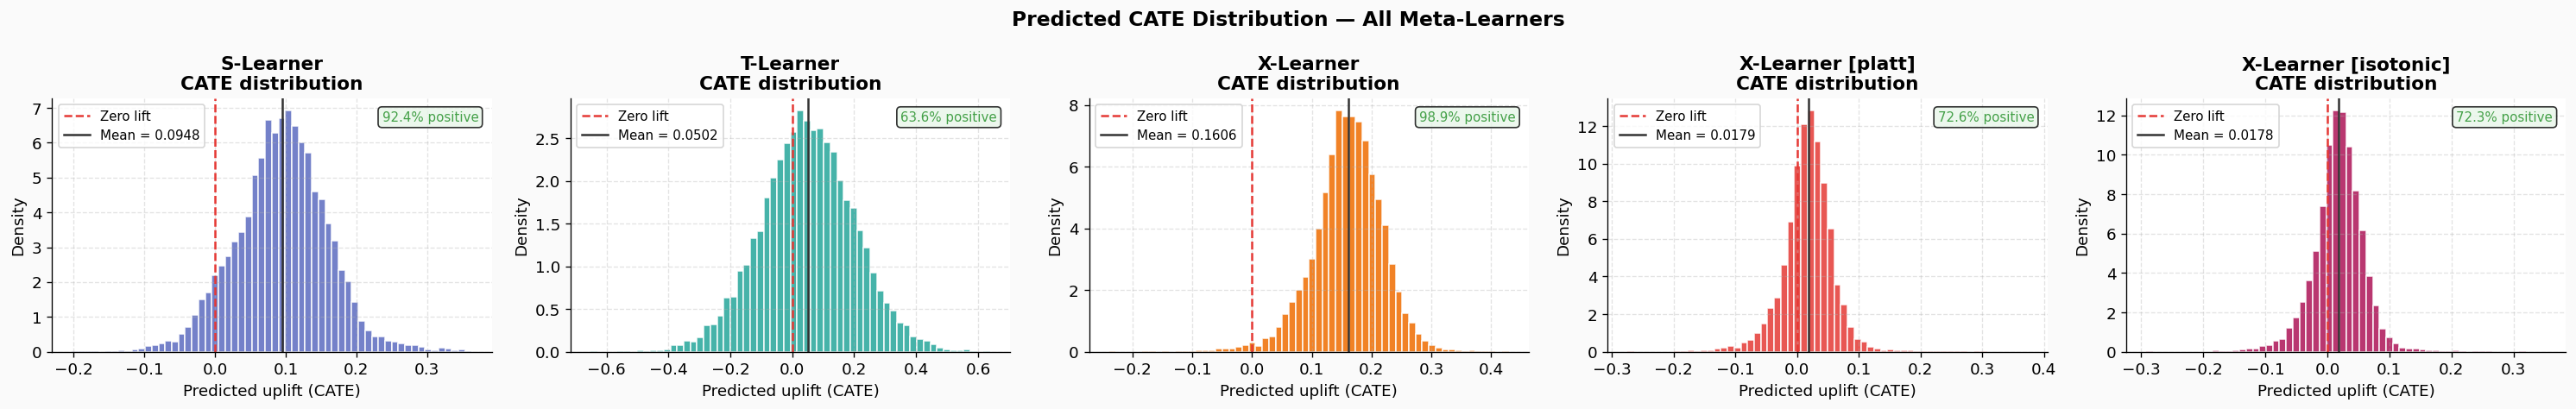

In [6]:
plot_uplift_distribution(cate_dict)
plt.show()

## 5. Qini Curve Evaluation — All Variants

In [7]:
auqc_dict = {name: auqc(y_te, t_te, cate) for name, cate in cate_dict.items()}

rows = []
for name, score in sorted(auqc_dict.items(), key=lambda x: -x[1]):
    parts   = name.split(' [')
    learner = parts[0]
    cal     = parts[1].rstrip(']') if len(parts) > 1 else 'none'
    rows.append({'Model': learner, 'Calibration': cal, 'AUQC': round(score, 4)})

pd.DataFrame(rows)

,Model,Calibration,AUQC
0,X-Learner,none,255.3192
1,S-Learner,none,255.0386
2,X-Learner,isotonic,254.5739
3,X-Learner,platt,252.8702
4,T-Learner,none,243.9957


[viz] Saved → outputs/figures/03_qini_curves.png


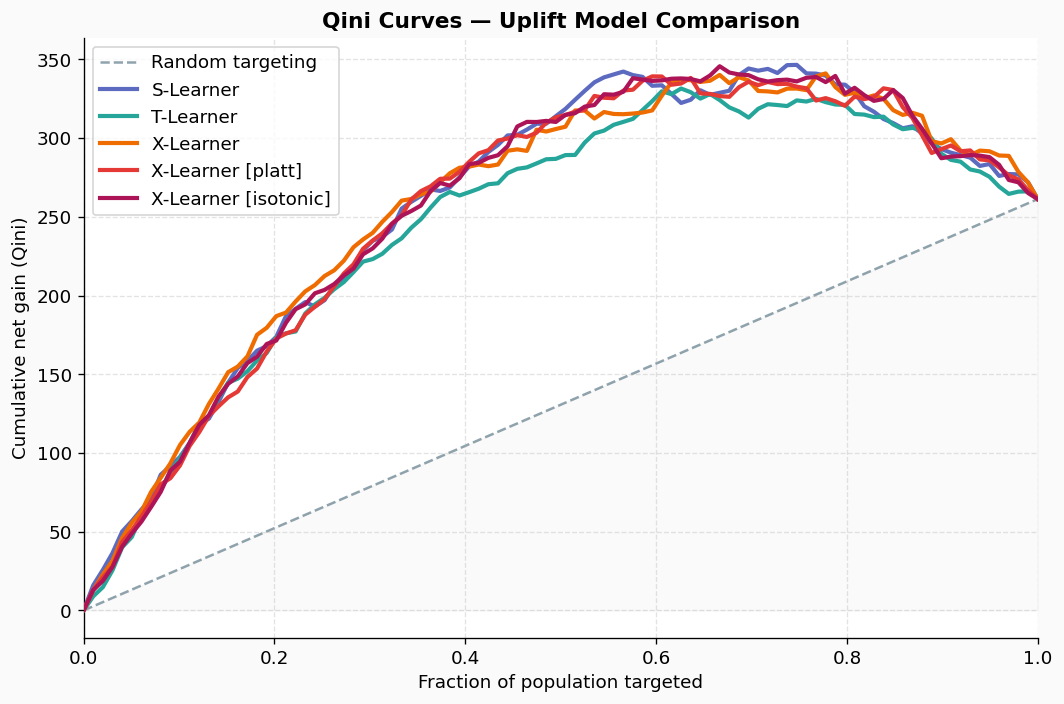

In [8]:
plot_qini_curves(cate_dict, y_te, t_te)
plt.show()

[viz] Saved → outputs/figures/08_model_comparison.png


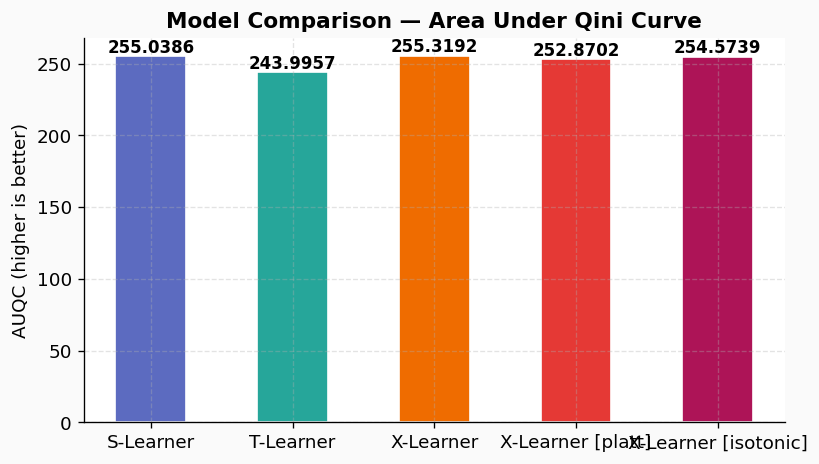

In [9]:
plot_model_comparison(auqc_dict)
plt.show()

## 6. Targeting Policy

In [10]:
best_name = max(auqc_dict, key=auqc_dict.get)
best_cate = cate_dict[best_name]

rows = []
for b in [0.10, 0.20, 0.30, 0.50]:
    pol = policy_summary(best_cate, y_te, t_te, budget_frac=b)
    rows.append({
        'Budget':               f"{b*100:.0f}%",
        'Customers targeted':   f"{pol['n_targeted']:,}",
        'Profit lift ($)':      f"{pol['profit_lift_usd']:,.0f}",
        'ROI (%)':              f"{pol['roi_pct']:.0f}%",
    })

print(f'Best model: {best_name}')
pd.DataFrame(rows).set_index('Budget')

Best model: X-Learner


,Customers targeted,Profit lift ($),ROI (%)
Budget,,,
10%,"1,920","3,068",320%
20%,"3,840","4,801",250%
30%,"5,760","5,388",187%
50%,"9,600","6,112",127%


[viz] Saved → outputs/figures/06_budget_curve.png


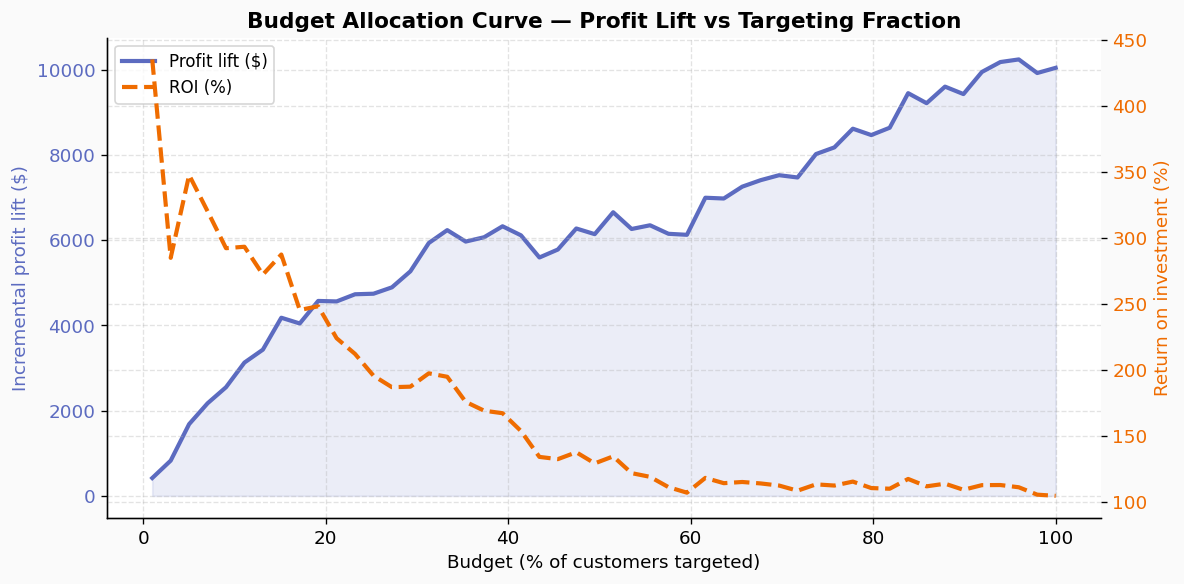

,Value
Best model,X-Learner
Optimal budget,96.0%
Profit lift,"$10,238.77"


In [11]:
bdf = budget_sweep(best_cate, y_te, t_te)
plot_budget_curve(bdf)
plt.show()

opt = bdf.loc[bdf['profit_lift_usd'].idxmax()]
pd.Series({
    'Best model':      best_name,
    'Optimal budget':  f"{opt['budget_frac']*100:.1f}%",
    'Profit lift':     f"${opt['profit_lift_usd']:,.2f}",
}).to_frame('Value')

## 7. CATE Heatmap — Who Are the Persuadables?

[viz] Saved → outputs/figures/07_cate_heatmap.png


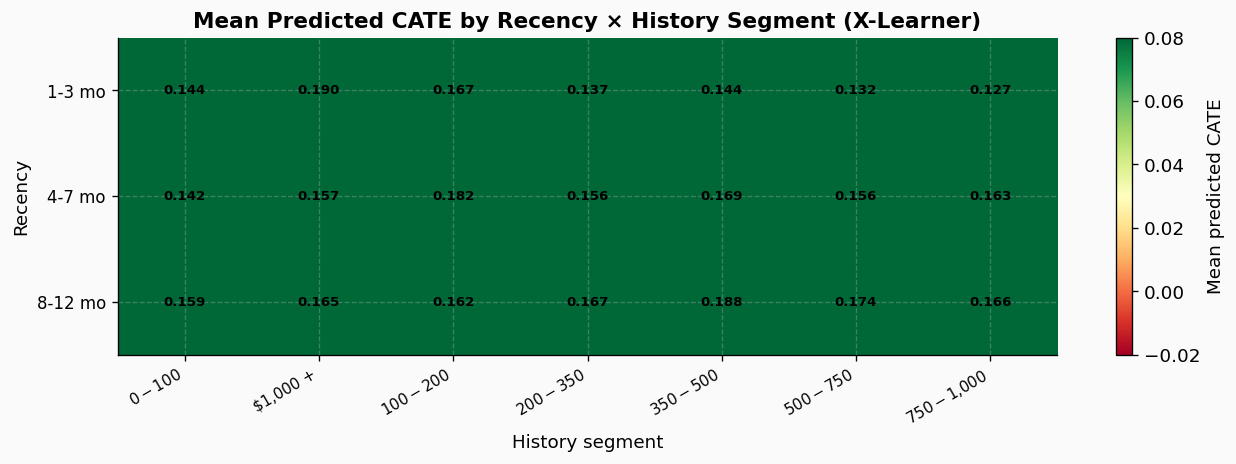

In [12]:
df_test = df.iloc[y_te.shape[0]*-1:].copy()  # approximate slice for display
# Use the first len(best_cate) rows of df as the test frame
from sklearn.model_selection import train_test_split
_, _, _, _, _, _, idx_tr, idx_te = train_test_split(
    X, treatment, y, df.index,
    test_size=0.30, random_state=42, stratify=treatment
)
df_test = df.loc[idx_te].reset_index(drop=True)

plot_cate_heatmap(df_test, best_cate, model_name=best_name)
plt.show()

## 8. Feature Importance (T-Learner)

[viz] Saved → outputs/figures/05_feature_importance.png


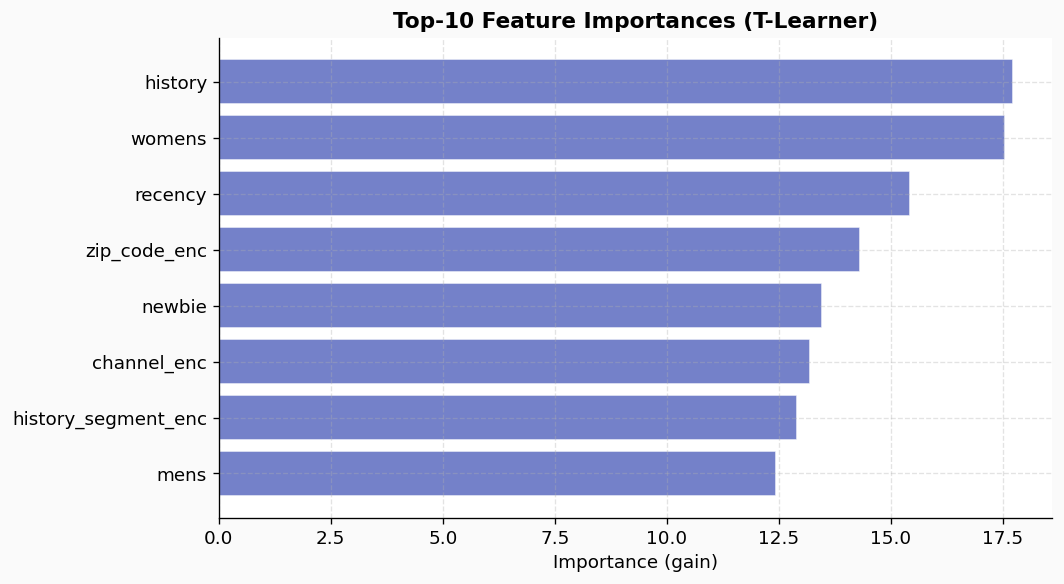

In [13]:
t_learner = next(m for m in models if m.name == 'T-Learner')
plot_feature_importance(t_learner, feature_cols)
plt.show()

---
## Summary

Key improvements over the baseline:
- **scale_pos_weight** computed per arm from training data (~16× for full dataset, slightly different per arm)
- **Platt scaling** (logistic regression on held-out predictions) corrects probability compression
- **Isotonic regression** (non-parametric, more flexible) corrects probability compression

The AUQC table in Section 5 shows the impact of each correction.
Calibration matters most for the X-Learner because μ₀ and μ₁ feed directly
into Stage 2 residuals D₁ = y − μ₀(x) and D₀ = μ₁(x) − y, where
miscalibration is one-sided and does not cancel out.